In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [45]:
now = datetime.now()


start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'

# importing data from yahoo finance
df = yf.download(ticker, start, end)   # ticker - Symbol , start - previous stock data , end - now

df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-29,21.230274,21.452226,20.951704,21.286894,274126000
2016-05-02,21.207628,21.307280,20.926793,21.282367,192640400
2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200
2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000
2016-05-05,21.245613,21.434737,21.118012,21.418787,143562000
...,...,...,...,...,...
2026-04-22,273.170013,273.739990,266.869995,267.820007,43249200
2026-04-23,273.429993,275.769989,271.649994,275.049988,33399600


In [46]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-29,21.230274,21.452226,20.951704,21.286894,274126000
2016-05-02,21.207628,21.307280,20.926793,21.282367,192640400
2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200
2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000
2016-05-05,21.245613,21.434737,21.118012,21.418787,143562000


In [47]:
# reset index 
df = df.reset_index()

In [48]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-04-29,21.230274,21.452226,20.951704,21.286894,274126000
1,2016-05-02,21.207628,21.307280,20.926793,21.282367,192640400
2,2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200
3,2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000
4,2016-05-05,21.245613,21.434737,21.118012,21.418787,143562000


Text(0, 0.5, 'Close price')

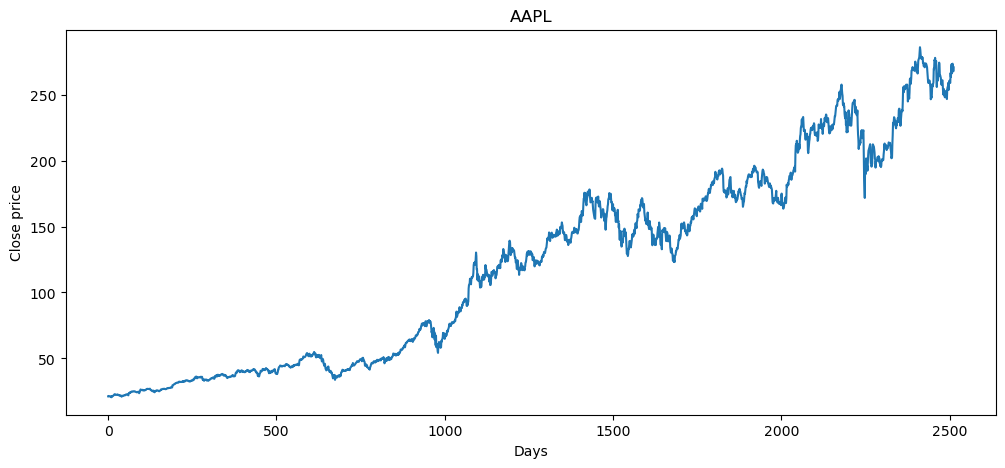

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)

plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

# 3. Feature Engineering

### 100 days Moving Average

In [50]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-04-29,21.230274,21.452226,20.951704,21.286894,274126000,NaN
1,2016-05-02,21.207628,21.307280,20.926793,21.282367,192640400,NaN
2,2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200,NaN
3,2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000,NaN
4,2016-05-05,21.245613,21.434737,21.118012,21.418787,143562000,NaN


In [51]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-04-29,21.230274,21.452226,20.951704,21.286894,274126000,NaN
1,2016-05-02,21.207628,21.307280,20.926793,21.282367,192640400,NaN
2,2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200,NaN
3,2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000,NaN
4,2016-05-05,21.245613,21.434737,21.118012,21.418787,143562000,NaN
...,...,...,...,...,...,...,...
98,2016-09-19,26.020466,26.616109,25.944865,26.389307,188092000,NaN
99,2016-09-20,26.018177,26.144179,25.775338,25.899049,138057200,23.014764
100,2016-09-21,26.013597,26.114398,25.759303,26.082325,144012800,23.062598


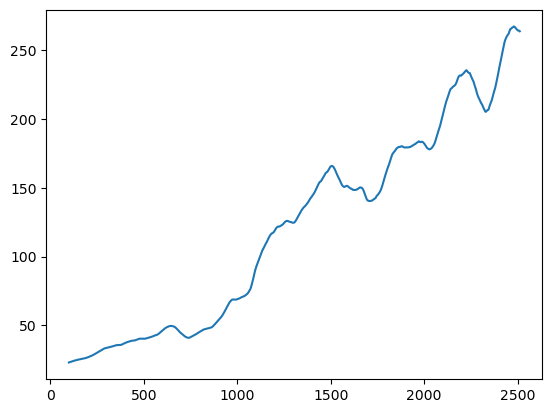

In [52]:
plt.plot(df['MA_100'])

Text(0, 0.5, 'Price')

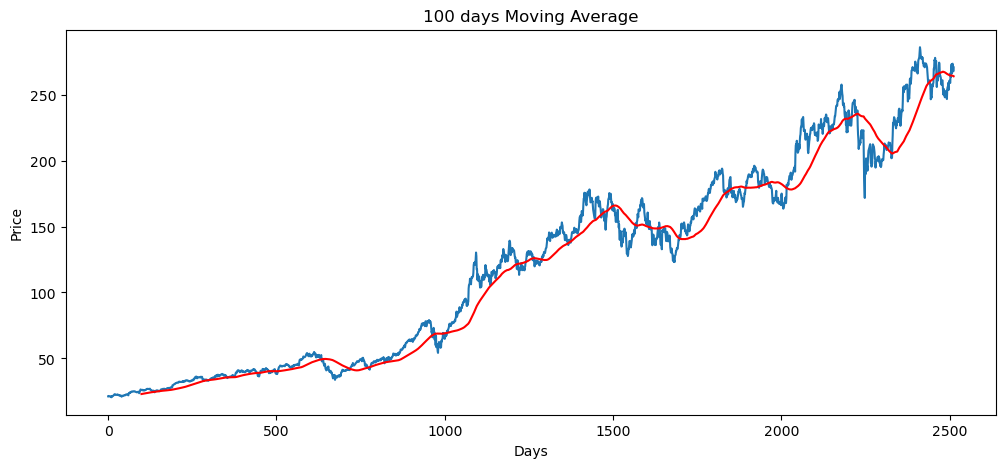

In [53]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)   # cose chart
plt.plot(df['MA_100'], 'r')  # Moving Average
plt.title('100 days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

## 200 days Moving Average

In [54]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(205)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-04-29,21.230274,21.452226,20.951704,21.286894,274126000,NaN,NaN
1,2016-05-02,21.207628,21.307280,20.926793,21.282367,192640400,NaN,NaN
2,2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200,NaN,NaN
3,2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000,NaN,NaN
4,2016-05-05,21.245613,21.434737,21.118012,21.418787,143562000,NaN,NaN
...,...,...,...,...,...,...,...,...
200,2017-02-14,31.225845,31.242032,30.816499,30.867379,132904800,26.770727,24.916662
201,2017-02-15,31.339184,31.514950,31.133355,31.341499,142492400,26.821532,24.967320
202,2017-02-16,31.302177,31.429372,31.184228,31.376181,90338400,26.876342,25.016049


Text(0, 0.5, 'Price')

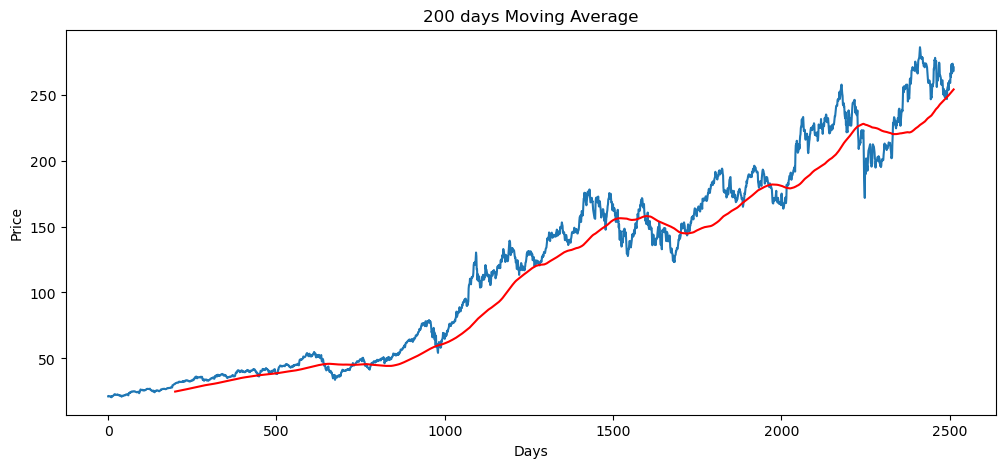

In [55]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)                    # Close chart
plt.plot(df['MA_200'], 'r')           # Moving Average
plt.title('200 days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

### 3 lines - Close , MA100 , MA200

Text(0, 0.5, 'Price')

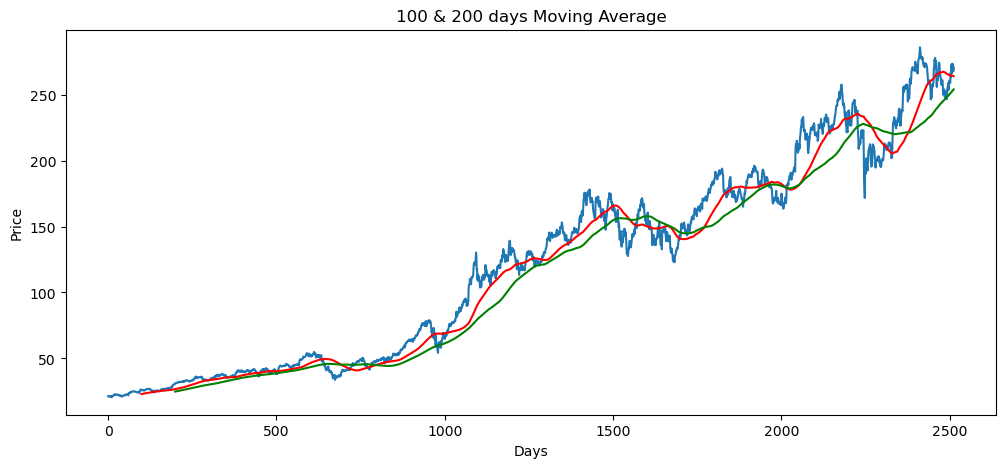

In [56]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)  
df['MA_100'] = df.Close.rolling(100).mean()
plt.plot(df['MA_100'], 'r') 
df['MA_200'] = df.Close.rolling(200).mean()
plt.plot(df['MA_200'], 'g') 
plt.title('100 & 200 days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

In [57]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-04-29,21.230274,21.452226,20.951704,21.286894,274126000,NaN,NaN
1,2016-05-02,21.207628,21.307280,20.926793,21.282367,192640400,NaN,NaN
2,2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200,NaN,NaN
3,2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000,NaN,NaN
4,2016-05-05,21.245613,21.434737,21.118012,21.418787,143562000,NaN,NaN
...,...,...,...,...,...,...,...,...
2508,2026-04-22,273.170013,273.739990,266.869995,267.820007,43249200,264.324191,252.719730
2509,2026-04-23,273.429993,275.769989,271.649994,275.049988,33399600,264.285586,253.040016
2510,2026-04-24,271.059998,273.059998,269.649994,272.760010,38157100,264.210292,253.342819


### Calculate % changed in each trading session

In [58]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,21.230274,NaN
1,21.207628,-0.001067
2,21.556410,0.016446
3,21.332195,-0.010401
4,21.245613,-0.004059
...,...,...
2508,273.170013,0.026299
2509,273.429993,0.000952
2510,271.059998,-0.008668


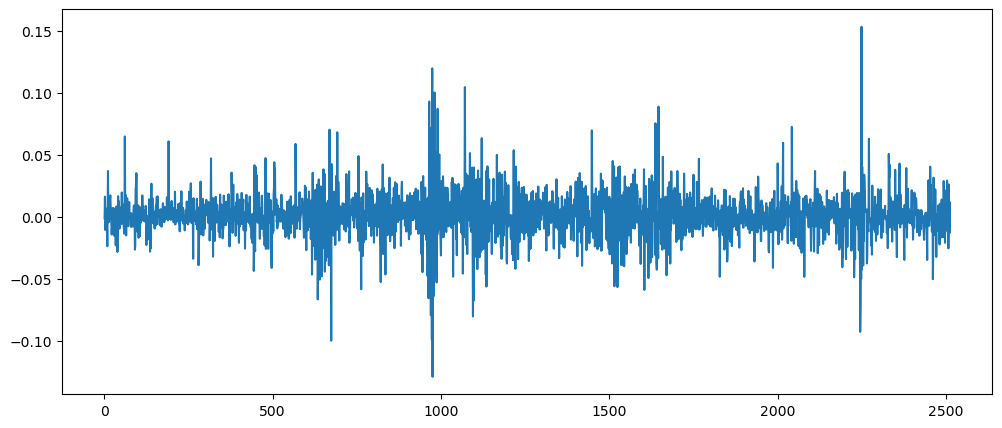

In [59]:
plt.figure(figsize=(12, 5))
#plt.plot(df.Close) 
plt.plot(df['Percentage Changed'])  

## 4. Data Preprocessing

In [60]:
df.shape

(2513, 9)

In [61]:
# Splitting Data into Training & Testing Datasets

# Data Training
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])  # 0-70%

# Data Testing
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7) : int(len(df))]) # 70-100%

print(data_training)
print(data_testing)

Ticker        AAPL
0        21.230274
1        21.207628
2        21.556410
3        21.332195
4        21.245613
...            ...
1754    165.236206
1755    164.270203
1756    162.663467
1757    162.969055
1758    161.431335

[1759 rows x 1 columns]
Ticker        AAPL
1759    161.421478
1760    166.005096
1761    167.256943
1762    167.168182
1763    166.133209
...            ...
2508    273.170013
2509    273.429993
2510    271.059998
2511    267.609985
2512    270.709991

[754 rows x 1 columns]


In [62]:
type(data_training)   

pandas.DataFrame

In [63]:
# Data Training
data_training

Ticker,AAPL
0,21.230274
1,21.207628
2,21.556410
3,21.332195
4,21.245613
...,...
1754,165.236206
1755,164.270203
1756,162.663467
1757,162.969055


In [64]:
# Data Testing
data_testing

Ticker,AAPL
1759,161.421478
1760,166.005096
1761,167.256943
1762,167.168182
1763,166.133209
...,...
2508,273.170013
2509,273.429993
2510,271.059998
2511,267.609985


In [65]:
# Scaling down the data between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1)) # fit the data in between 0 and 1.

In [66]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00409763],
       [0.00395387],
       [0.00616809],
       ...,
       [0.90197888],
       [0.90391889],
       [0.89415676]], shape=(1759, 1))

In [67]:
type(data_training_array)

numpy.ndarray

In [68]:
data_training_array.shape

(1759, 1)

# 5. Sequence Creation

In [69]:
# Example
# 12, 15, 10, 14, 16, 18, 19, 20, 21, 20       22
# x train                                      # y train

In [70]:
x_train = []
y_train = []


# for i in range(100, 1759)
for i in range(100, data_training_array.shape[0]):     # (1759, 1)    , 1759 is index 0 and 1 is index 1
    x_train.append(data_training_array[i-100: i])     # i=100  , 100-100=0  oth index
    y_train.append(data_training_array[i, 0])

In [71]:
x_train


[array([[0.00409763],
        [0.00395387],
        [0.00616809],
        [0.00474467],
        [0.00419501],
        [0.00344278],
        [0.00354405],
        [0.00445537],
        [0.00313902],
        [0.        ],
        [0.00026031],
        [0.00512077],
        [0.00455661],
        [0.00610446],
        [0.00558369],
        [0.00705917],
        [0.00880951],
        [0.0109359 ],
        [0.01342401],
        [0.01456672],
        [0.01447997],
        [0.01377114],
        [0.01174602],
        [0.01067555],
        [0.01096484],
        [0.0119919 ],
        [0.01257051],
        [0.01244035],
        [0.01346737],
        [0.01228118],
        [0.01012587],
        [0.01029942],
        [0.00983655],
        [0.01042966],
        [0.00721829],
        [0.00688558],
        [0.0080573 ],
        [0.00753651],
        [0.00833216],
        [0.00442646],
        [0.0024591 ],
        [0.00470124],
        [0.00587296],
        [0.00760883],
        [0.00802836],
        [0

In [72]:
y_train

[np.float64(0.03446431205503997),
 np.float64(0.03602047417052537),
 np.float64(0.03324258021646634),
 np.float64(0.03348985204690244),
 np.float64(0.03379528197937001),
 np.float64(0.03504600205368452),
 np.float64(0.03247175227201049),
 np.float64(0.03373709965993191),
 np.float64(0.032966283824179404),
 np.float64(0.0336643626791068),
 np.float64(0.03373709965993191),
 np.float64(0.03495875884628566),
 np.float64(0.03520603067672176),
 np.float64(0.03810027716095371),
 np.float64(0.03846387730415607),
 np.float64(0.03997641176159039),
 np.float64(0.03945285564757067),
 np.float64(0.040398194224230854),
 np.float64(0.04028185380276128),
 np.float64(0.04016547705518175),
 np.float64(0.03965647560254906),
 np.float64(0.03956919606904025),
 np.float64(0.03890020231948024),
 np.float64(0.040427303547004884),
 np.float64(0.04129990514283996),
 np.float64(0.03743127130269039),
 np.float64(0.03581690265036025),
 np.float64(0.034711547559366146),
 np.float64(0.03444974528494965),
 np.float64

In [73]:
# convert into numPy arrays
x_train , y_train = np.array(x_train), np.array(y_train)

In [74]:
x_train

array([[[0.00409763],
        [0.00395387],
        [0.00616809],
        ...,
        [0.0364568 ],
        [0.03450792],
        [0.03449339]],

       [[0.00395387],
        [0.00616809],
        [0.00474467],
        ...,
        [0.03450792],
        [0.03449339],
        [0.03446431]],

       [[0.00616809],
        [0.00474467],
        [0.00419501],
        ...,
        [0.03449339],
        [0.03446431],
        [0.03602047]],

       ...,

       [[0.79474663],
        [0.77044097],
        [0.75138401],
        ...,
        [0.91105266],
        [0.91831178],
        [0.91217916]],

       [[0.77044097],
        [0.75138401],
        [0.79424678],
        ...,
        [0.91831178],
        [0.91217916],
        [0.90197888]],

       [[0.75138401],
        [0.79424678],
        [0.79599625],
        ...,
        [0.91217916],
        [0.90197888],
        [0.90391889]]], shape=(1659, 100, 1))

In [75]:
x_train.ndim

3

In [76]:
y_train

array([0.03446431, 0.03602047, 0.03324258, ..., 0.90197888, 0.90391889,
       0.89415676], shape=(1659,))

In [77]:
y_train.ndim

1

# 6. Model Building

### Building Machine Learning Model

In [78]:
# kera is high level api for building neural networks

In [79]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [80]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM ,Input

In [81]:
# Initialize
model = Sequential()  # accepts of sequence of data , mainly use for LSTM models

# add input
# 100 days data , then processing then gives tommorow expected close price data
model.add(Input(shape=(100, 1))) # we accepting input data, model will expect 100 days of previous data with 

# LSTM layer
model.add(LSTM(units=128, activation='tanh', return_sequences=True))  # 128 neuron , tanh means hyperbolic tangent, ( default activation function ), this helps to handle both positive and negative values , 

# Another LSTM layer
model.add(LSTM(units=64))   # By default return_sequences is false , single o/p - we do not have any return_sequences= True

model.add(Dense(25))        #  typicaly use first end of nueral network to transform learned feature of the final o/p

model.add(Dense(1))         # 25 o/p from the previous dense , then combains  them into single o/p

# 7 . Model Training

In [83]:
model.compile(optimizer='adam', loss='mean_squared_error') # optimizing algorithm adam is used to compile , mse
model.fit(x_train, y_train, epochs=50)  # asking to model learn/go through the x_train and y_train in 50 times


Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0102
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 6.7935e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 7.0576e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 6.4579e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 6.2457e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 6.3917e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 6.0255e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 5.4822e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 5.1045e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 4.9241e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 4.7885e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 5.4256e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 4.5308e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 4.0350e-04
Epoch 15/50
52/52 ━

In [84]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [85]:
# Save the trained model
model.save('stock_prediction_model.keras')  # we have already train the model, now if you use another dataset then you can use pretrained model
# thats why you do not have to train the model again and again , because it takes lot of time



# 8 Preparing Test Data

In [87]:
data_training

Ticker,AAPL
0,21.230274
1,21.207628
2,21.556410
3,21.332195
4,21.245613
...,...
1754,165.236206
1755,164.270203
1756,162.663467
1757,162.969055


In [88]:
data_testing

Ticker,AAPL
1759,161.421478
1760,166.005096
1761,167.256943
1762,167.168182
1763,166.133209
...,...
2508,273.170013
2509,273.429993
2510,271.059998
2511,267.609985


In [89]:
data_training.tail(100)

Ticker,AAPL
1659,145.693634
1660,145.969208
1661,145.477127
1662,144.315750
1663,140.654449
...,...
1754,165.236206
1755,164.270203
1756,162.663467
1757,162.969055


In [90]:
past_100_days = data_training.tail(100)

In [91]:
past_100_days

Ticker,AAPL
1659,145.693634
1660,145.969208
1661,145.477127
1662,144.315750
1663,140.654449
...,...
1754,165.236206
1755,164.270203
1756,162.663467
1757,162.969055


In [92]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,145.693634
1,145.969208
2,145.477127
3,144.315750
4,140.654449
...,...
849,273.170013
850,273.429993
851,271.059998
852,267.609985


In [93]:
# scale
input_data = scaler.fit_transform(final_df)
input_data

array([[1.39043669e-01],
       [1.40735596e-01],
       [1.37714391e-01],
       [1.30583939e-01],
       [1.08104823e-01],
       [9.62004385e-02],
       [1.06533841e-01],
       [1.03572969e-01],
       [1.17652407e-01],
       [1.23574246e-01],
       [1.09917789e-01],
       [6.93707460e-02],
       [5.73456970e-02],
       [4.44142585e-02],
       [4.39911831e-02],
       [6.30259255e-02],
       [4.35682950e-02],
       [4.13324404e-02],
       [3.02743943e-02],
       [6.16363624e-03],
       [2.77363162e-02],
       [2.96699004e-02],
       [3.02223530e-04],
       [8.09736094e-03],
       [0.00000000e+00],
       [2.77966017e-02],
       [3.09992249e-02],
       [3.45042122e-02],
       [5.11822481e-02],
       [5.06987467e-02],
       [5.88564399e-02],
       [6.59869854e-02],
       [6.15757022e-02],
       [6.19383517e-02],
       [7.76493848e-02],
       [9.72279610e-02],
       [1.05808636e-01],
       [1.01760002e-01],
       [1.14449737e-01],
       [1.26354028e-01],


In [94]:
input_data.shape

(854, 1)

In [95]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [96]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [97]:
x_test

array([[[0.13904367],
        [0.1407356 ],
        [0.13771439],
        ...,
        [0.24323256],
        [0.24510876],
        [0.2356677 ]],

       [[0.1407356 ],
        [0.13771439],
        [0.13058394],
        ...,
        [0.24510876],
        [0.2356677 ],
        [0.23560718]],

       [[0.13771439],
        [0.13058394],
        [0.10810482],
        ...,
        [0.2356677 ],
        [0.23560718],
        [0.263749  ]],

       ...,

       [[0.95497713],
        [0.98104629],
        [1.        ],
        ...,
        [0.87872686],
        [0.92170443],
        [0.92330061]],

       [[0.98104629],
        [1.        ],
        [0.98748686],
        ...,
        [0.92170443],
        [0.92330061],
        [0.90874967]],

       [[1.        ],
        [0.98748686],
        [0.96632484],
        ...,
        [0.92330061],
        [0.90874967],
        [0.88756779]]], shape=(754, 100, 1))

In [98]:
y_test

array([0.23560718, 0.263749  , 0.27143491, 0.27088995, 0.26453557,
       0.25793902, 0.24789257, 0.29497696, 0.29455341, 0.28408333,
       0.29491653, 0.29606631, 0.29036978, 0.28733958, 0.28733958,
       0.29109677, 0.30539927, 0.30606583, 0.30024798, 0.28424868,
       0.28594566, 0.29291507, 0.3077022 , 0.31903511, 0.31873195,
       0.33594333, 0.34115523, 0.3328527 , 0.33061039, 0.32218644,
       0.33885239, 0.34121594, 0.35836661, 0.35545773, 0.35933633,
       0.37182062, 0.36521498, 0.36576022, 0.35939694, 0.3778204 ,
       0.37588115, 0.36733607, 0.38424438, 0.39145615, 0.39351682,
       0.42006115, 0.41091004, 0.40406176, 0.40697064, 0.40012245,
       0.38757765, 0.38436552, 0.39460767, 0.39927415, 0.40018316,
       0.42018247, 0.41860662, 0.42690905, 0.41497038, 0.40775861,
       0.41266735, 0.41794006, 0.423273  , 0.41551581, 0.43133336,
       0.43509063, 0.43000005, 0.41163702, 0.40309213, 0.34745808,
       0.32842859, 0.33418592, 0.32442876, 0.32309546, 0.32345

# 9. Making Prediction

In [104]:
# predicted price
y_predicted = model.predict(x_test)    

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [100]:
y_test  # original price

array([0.23560718, 0.263749  , 0.27143491, 0.27088995, 0.26453557,
       0.25793902, 0.24789257, 0.29497696, 0.29455341, 0.28408333,
       0.29491653, 0.29606631, 0.29036978, 0.28733958, 0.28733958,
       0.29109677, 0.30539927, 0.30606583, 0.30024798, 0.28424868,
       0.28594566, 0.29291507, 0.3077022 , 0.31903511, 0.31873195,
       0.33594333, 0.34115523, 0.3328527 , 0.33061039, 0.32218644,
       0.33885239, 0.34121594, 0.35836661, 0.35545773, 0.35933633,
       0.37182062, 0.36521498, 0.36576022, 0.35939694, 0.3778204 ,
       0.37588115, 0.36733607, 0.38424438, 0.39145615, 0.39351682,
       0.42006115, 0.41091004, 0.40406176, 0.40697064, 0.40012245,
       0.38757765, 0.38436552, 0.39460767, 0.39927415, 0.40018316,
       0.42018247, 0.41860662, 0.42690905, 0.41497038, 0.40775861,
       0.41266735, 0.41794006, 0.423273  , 0.41551581, 0.43133336,
       0.43509063, 0.43000005, 0.41163702, 0.40309213, 0.34745808,
       0.32842859, 0.33418592, 0.32442876, 0.32309546, 0.32345

In [101]:
# differents between y_predicted  and y_test
# y_predicted -  is scaled data
# reverting the scaled data to the original data called Inverse Transform

In [105]:
# reverting the scaled data to the original data called Inverse Transform
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()   #  -1 is row , 1 column
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [106]:
y_predicted

array([162.92192, 162.38716, 164.41554, 166.50824, 167.54494, 167.37091,
       166.55493, 165.23523, 168.38654, 170.6501 , 170.74777, 171.39848,
       171.893  , 171.62549, 171.13544, 170.87376, 171.1065 , 172.52817,
       173.43518, 173.27486, 171.64658, 170.81656, 171.12811, 172.72571,
       174.67273, 175.61029, 177.44948, 178.89723, 178.74396, 178.26671,
       177.25275, 178.26826, 179.22166, 181.24522, 181.99953, 182.52351,
       183.90474, 183.96866, 183.88724, 183.22379, 184.65192, 185.32576,
       184.68315, 185.89368, 187.32529, 188.14362, 191.0606 , 191.54364,
       190.7526 , 190.59613, 189.92334, 188.35144, 187.31673, 187.98317,
       188.90504, 189.37883, 191.52048, 192.37833, 193.41167, 192.59007,
       191.34245, 191.33737, 192.03273, 192.94078, 192.50984, 193.83075,
       194.9132 , 194.75963, 192.65327, 190.78384, 184.52332, 179.80879,
       178.56184, 177.50252, 176.91158, 176.69447, 177.53079, 176.9061 ,
       175.94586, 174.07405, 173.37933, 173.9569 , 

In [107]:
y_test

array([161.42147827, 166.00509644, 167.25694275, 167.16818237,
       166.13320923, 165.05879211, 163.42247009, 171.09136963,
       171.02238464, 169.31706238, 171.08152771, 171.26879883,
       170.3409729 , 169.84742737, 169.84742737, 170.4593811 ,
       172.78890991, 172.8974762 , 171.94989014, 169.34399414,
       169.62039185, 170.75553894, 173.16400146, 175.00985718,
       174.96047974, 177.76379395, 178.61268616, 177.26040649,
       176.89518738, 175.52313232, 178.23760986, 178.62257385,
       181.41600037, 180.94221497, 181.57394409, 183.60733032,
       182.53143311, 182.62023926, 181.58381653, 184.58454895,
       184.26869202, 182.87690735, 185.63085938, 186.80548096,
       187.14111328, 191.46453857, 189.9740448 , 188.85862732,
       189.33241272, 188.2170105 , 186.17376709, 185.65058899,
       187.31878662, 188.07884216, 188.22689819, 191.48429871,
       191.22763062, 192.57989502, 190.63537598, 189.46075439,
       190.26026917, 191.11906433, 191.9876709 , 190.72

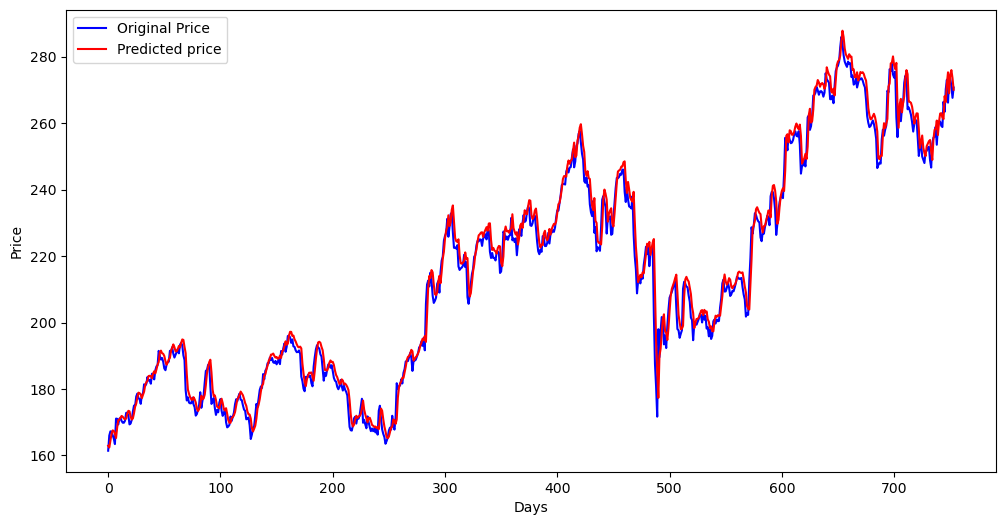

In [116]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()


(140.0, 220.0)

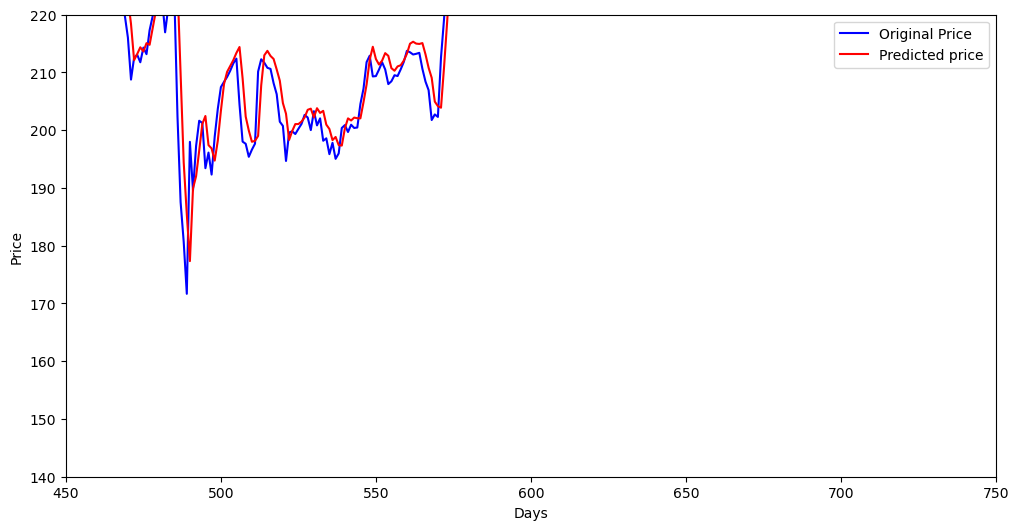

In [114]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(140, 220)

# 10. Model Evaluation

In [117]:
# 3 matrics
# 1. MSE - means squared error
# 2. RMSE - root means squared error
# 3. R-Squared

In [121]:
# import
from sklearn.metrics import mean_squared_error, r2_score

In [119]:
# 1. MSE - Means Squared Error
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")    # low mse means - prediction closer to the actual value

Mean Squared Error (MSE): 15.703521698933166


In [120]:
# 2. RMSE -root means squared error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 3.9627669246289474


In [122]:
# 3. R-Squared
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")   # which close to 1 (one) , so that prediction is very good

R-Squared: 0.9856987888674026
